In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Importer les données, vérifier types, dimensions et aperçu général.

In [3]:
df = pd.read_csv("../data/CardProfiler.csv")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CUST_ID                 8950 non-null   str    
 1   BALANCE                 8950 non-null   float64
 2   PURCHASES               8950 non-null   float64
 3   ONEOFF_PURCHASES        8950 non-null   float64
 4   INSTALLMENTS_PURCHASES  8950 non-null   float64
 5   CASH_ADVANCE            8950 non-null   float64
 6   CREDIT_LIMIT            8949 non-null   float64
 7   PAYMENTS                8950 non-null   float64
dtypes: float64(7), str(1)
memory usage: 559.5 KB


In [6]:
df.shape

(8950, 8)

In [8]:
df.describe()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000
mean,1564.474828,1003.204834,592.437371,411.067645,978.871112,4494.449450,1733.143852
std,2081.531879,2136.634782,1659.887917,904.338115,2097.163877,3638.815725,2895.063757
min,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000
25%,128.281915,39.635000,0.000000,0.000000,0.000000,1600.000000,383.276166
50%,873.385231,361.280000,38.000000,89.000000,0.000000,3000.000000,856.901546
75%,2054.140036,1110.130000,577.405000,468.637500,1113.821139,6500.000000,1901.134317
max,19043.138560,49039.570000,40761.250000,22500.000000,47137.211760,30000.000000,50721.483360


### Identifier valeurs manquantes et doublons.

In [12]:
df.isna().sum()

CUST_ID                   0
BALANCE                   0
PURCHASES                 0
ONEOFF_PURCHASES          0
INSTALLMENTS_PURCHASES    0
CASH_ADVANCE              0
CREDIT_LIMIT              1
PAYMENTS                  0
dtype: int64

In [16]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].mean())

In [18]:
df.duplicated().sum()

np.int64(0)

### Analyser la distribution des variables numériques : histogrammes + skewness affiché, pour repérer les variables asymétriques.

In [48]:
import matplotlib.pyplot as plt

In [57]:
import seaborn as sns

In [49]:
columns = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']

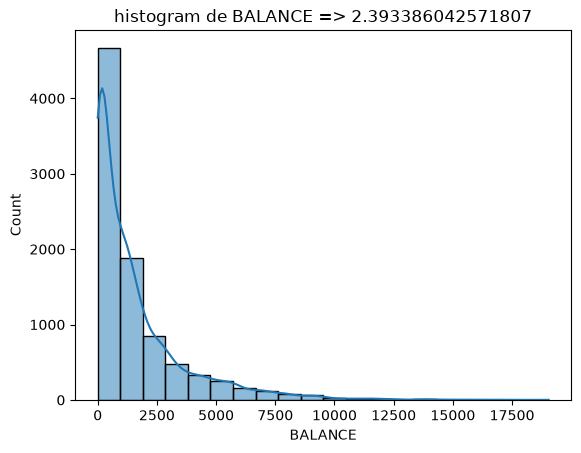

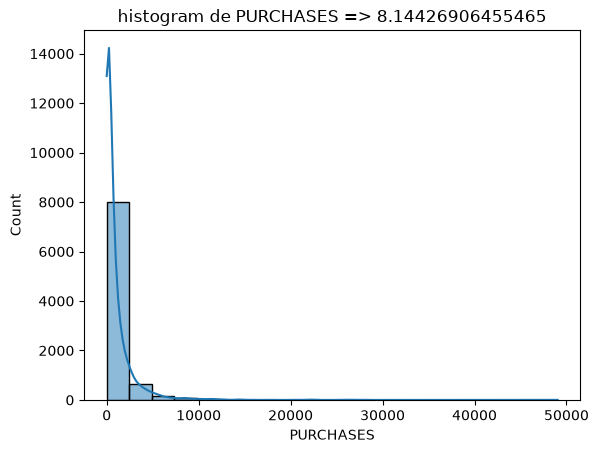

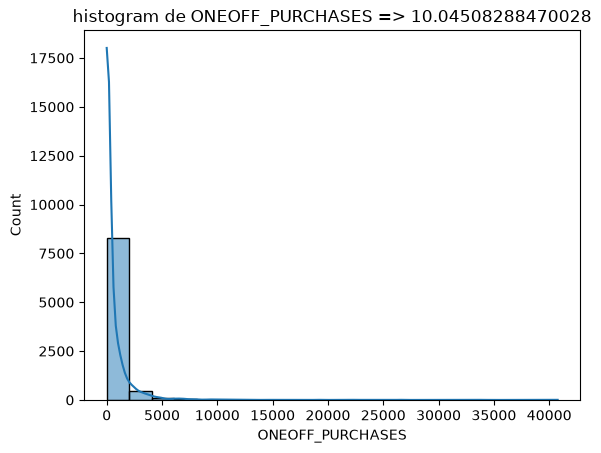

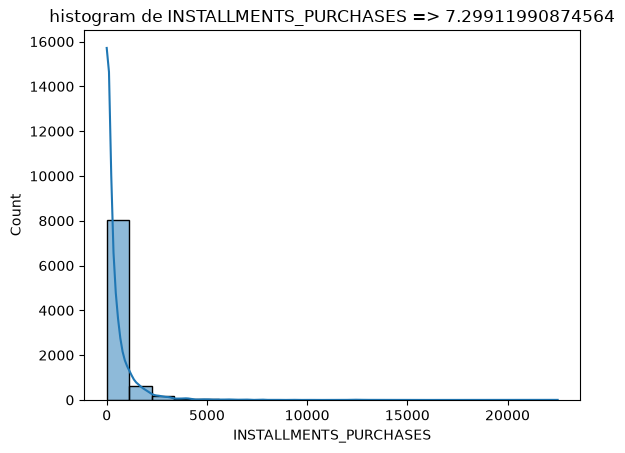

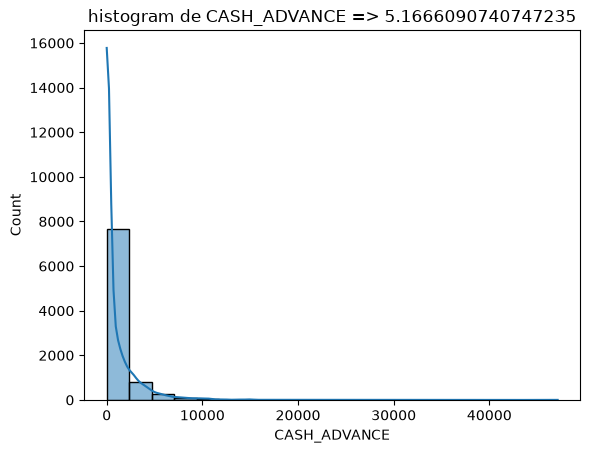

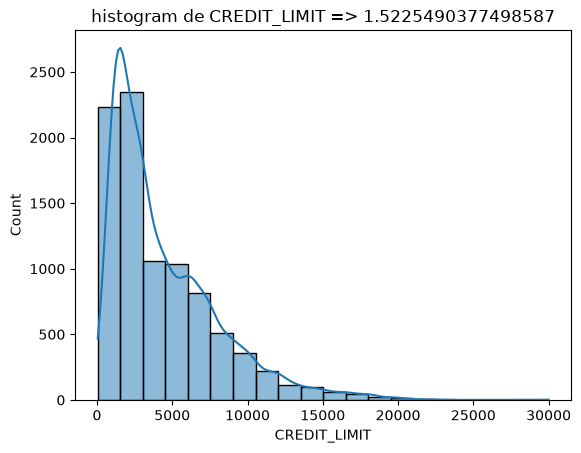

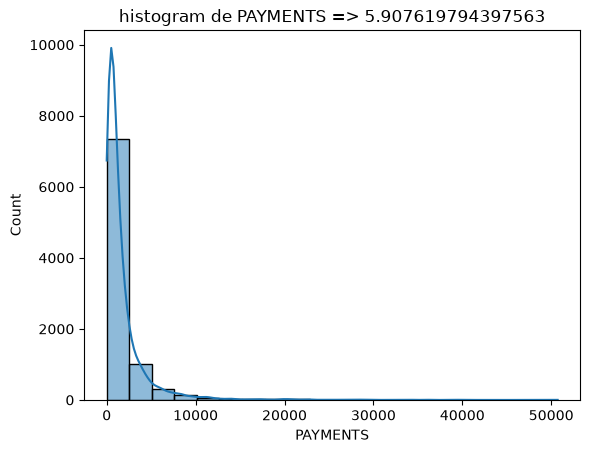

In [58]:
for col in columns:
    sns.histplot(df[col],bins=20,edgecolor='black',kde=True)
    plt.title(f'histogram de {col} => {df[col].skew()}')
    plt.show()

### Étudier les corrélations entre variables (heatmap de la matrice de corrélation).

In [53]:
corr = df.corr(numeric_only=True)

<Axes: >

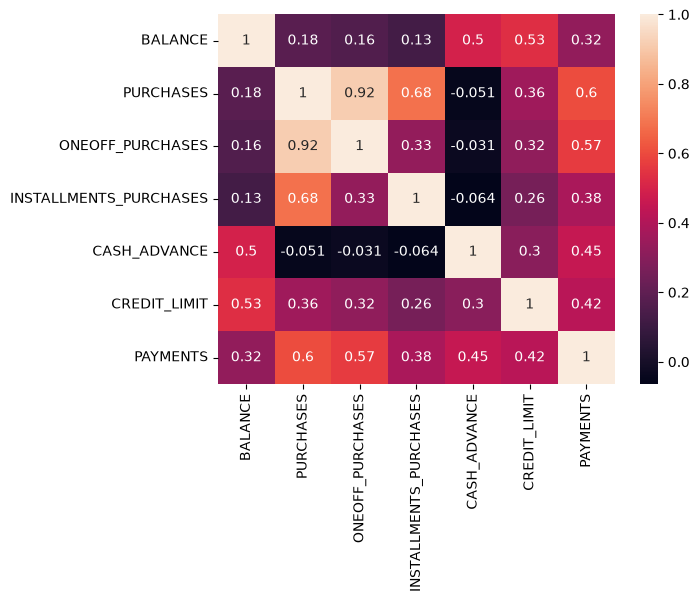

In [55]:
sns.heatmap(corr,annot=True)

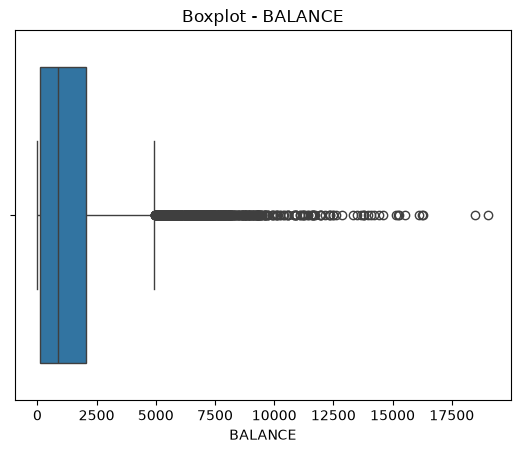

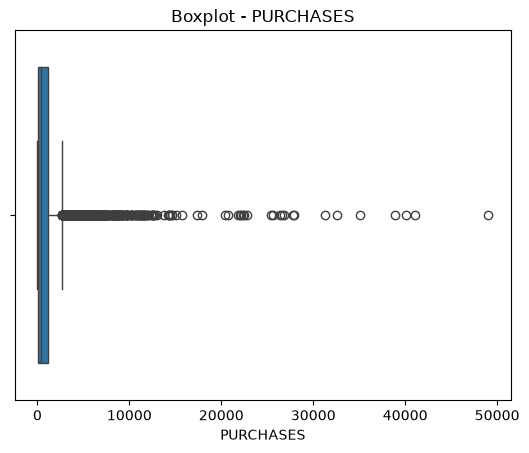

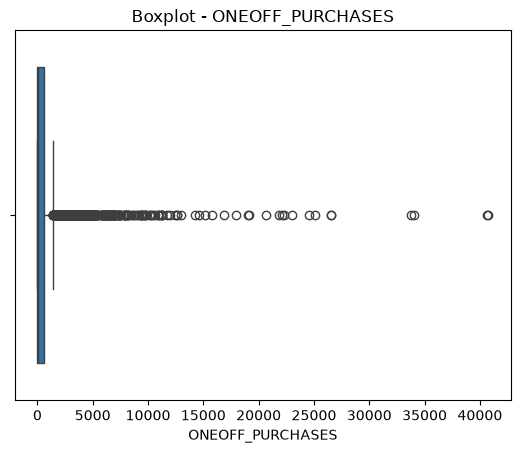

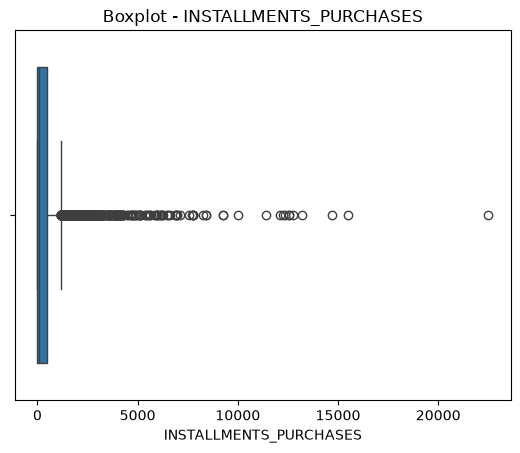

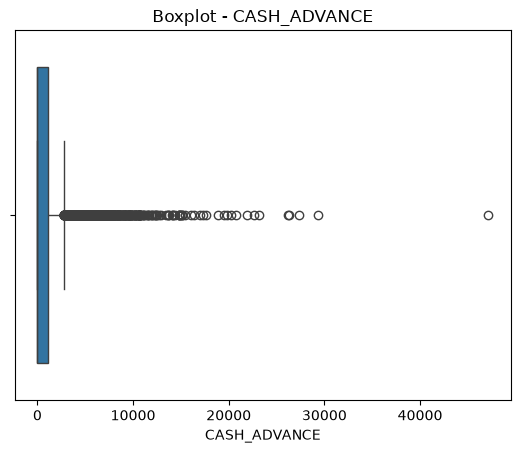

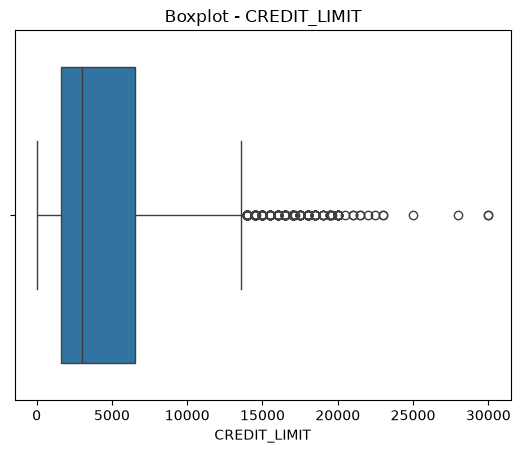

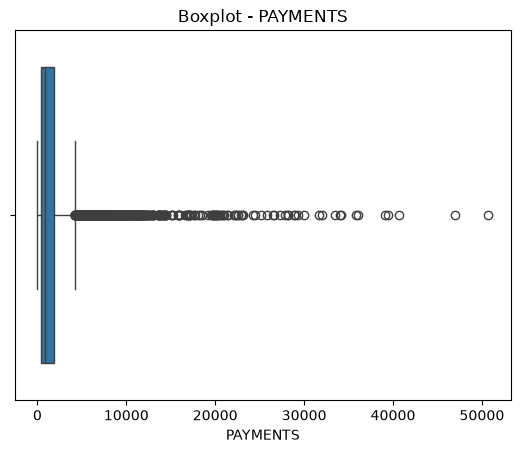

In [62]:
for col in columns:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()

In [70]:
# IQR = Q3 - Q1

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lowr = Q1 - (1.5*IQR)
    upper = Q3 + (1.5*IQR)
    nb_outlire = df[(df[col] < lowr) | (df[col] > upper)]
    print(f"{col} : {len(nb_outlire)}")

BALANCE : 695
PURCHASES : 808
ONEOFF_PURCHASES : 1013
INSTALLMENTS_PURCHASES : 867
CASH_ADVANCE : 1030
CREDIT_LIMIT : 248
PAYMENTS : 808


In [ ]:
# Z-scor = (x - mean) / std

for col in columns:
    